In [ ]:
# For Gpu setup
!nvidia-smi

Tue Mar 24 14:36:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# check gpu is working
import torch
print(torch.cuda.is_available())

True


In [ ]:
# Import the files of roboflow
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="8RRAkqmXcuvEFawT2jdA")
project = rf.workspace("palaks-workspace-bt0bl").project("ai-archaeological-site")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 13.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to AI-Archaeological-Site-1 in yolov8:: 100%|██████████| 254/254 [00:00<00:00, 6830.85it/s]


In [ ]:
!ls /content/AI-Archaeological-Site-1/train

images	labels


In [ ]:
train_path = "/content/AI-Archaeological-Site-1/train"
valid_path = "/content/AI-Archaeological-Site-1/valid"

In [ ]:
train_path = "/content/AI-Archaeological-Site-1/train"
valid_path = "/content/AI-Archaeological-Site-1/valid"

!ls {train_path}
!ls {valid_path}

images	labels
images	labels


In [ ]:
# Generate polygon masks
import os
import cv2
import numpy as np

def generate_masks_polygon(img_dir, label_dir, mask_dir):
    os.makedirs(mask_dir, exist_ok=True)  # create folder if missing
    for file in os.listdir(img_dir):
        if not file.endswith(".jpg"):
            continue
        img_path = os.path.join(img_dir, file)
        label_path = os.path.join(label_dir, file.replace(".jpg", ".txt"))
        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        with open(label_path) as f:
            for line in f.readlines():
                values = list(map(float, line.strip().split()))
                cls = int(values[0])
                coords = values[1:]
                pts = np.array(coords).reshape(-1, 2)
                pts[:,0] *= w
                pts[:,1] *= h
                pts = pts.astype(np.int32)
                cv2.fillPoly(mask, [pts], 255)

        cv2.imwrite(os.path.join(mask_dir, file), mask)

# Run for train & valid
train_path = "/content/AI-Archaeological-Site-1/train"
valid_path = "/content/AI-Archaeological-Site-1/valid"

generate_masks_polygon(train_path+"/images", train_path+"/labels", train_path+"/masks")
generate_masks_polygon(valid_path+"/images", valid_path+"/labels", valid_path+"/masks")

# Verify masks
!ls {train_path}/masks | head
!ls {valid_path}/masks | head

AjantaCaves_image_jpg.rf.0c4e54a1d5730e015c1e1d1520e5304f.jpg
AjantaCaves_image_jpg.rf.9449cd0be3d9c64883b52f53588fba4a.jpg
AjantaCaves_image_jpg.rf.b10a4b9c64bae13d22129a94b831de53.jpg
AjantaCaves_image_jpg.rf.fa306f669f7e290c0e6afddc4260152a.jpg
Banawali_image_jpg.rf.7e555ff2a67e76c7ead8fd028e59a3c5.jpg
Banawali_image_jpg.rf.9478700573af8f253406d8cd99e5e74f.jpg
Banawali_image_jpg.rf.97528cf1baa59ee087de4c168acdd2b6.jpg
Banawali_image_jpg.rf.f4ad3fc774176222812ec9f71c9146c1.jpg
ChitradurgaFort_image_jpeg.rf.c54c597b476ecaf334bbbc0d6d87791c.jpg
ChitradurgaFort_image_jpeg.rf.d9c5a1033fbdb50bba881ca78ea7b91d.jpg
Amravati_image_jpg.rf.f21e1449f4d6a751e40b31a39bff102a.jpg
Dholavira_image_jpg.rf.3608d0e34a4e4a2f89d1c459dfd84eb7.jpg
IskconTemple_image_jpg.rf.fb64512b31a54be66360752d1085e953.jpg
Mahabalipuram_image_jpg.rf.cfb8f39b79299ac927e8734c79c897f7.jpg
Mehrauli_image_jpg.rf.2a164cb56805c016c75ebba9e637564e.jpg
Nalanda_image_jpg.rf.1867615dda86370b1bf43b0548ab19f6.jpg
Peru_image_jpg.rf.9

In [ ]:
#U-net dataset loader
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import os

class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = os.listdir(img_dir)
        self.transform = T.Compose([
            T.Resize((256,256)),
            T.ToTensor()
        ])
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        file = self.files[idx]
        img = Image.open(os.path.join(self.img_dir, file)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, file)).convert("L")
        img = self.transform(img)
        mask = self.transform(mask)
        return img, mask

train_dataset = SegDataset(train_path+"/images", train_path+"/masks")
val_dataset = SegDataset(valid_path+"/images", valid_path+"/masks")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
#U-net model, apply loss and optimizer
!pip install segmentation-models-pytorch

import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)
model.to(device)

loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
# U-net training loop + IoU/Dice Validation
from tqdm import tqdm

def dice_coef(pred, target, smooth=1.):
    pred = (pred > 0.5).float()
    target = target.float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

epochs = 10  # for testing, baad me increase
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for imgs, masks in tqdm(train_loader):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}")

    # Validation
    model.eval()
    dice_score = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            dice_score += dice_coef(preds, masks).item()
    print(f"Epoch {epoch+1}, Validation Dice: {dice_score/len(val_loader):.4f}")

100%|██████████| 15/15 [00:06<00:00,  2.49it/s]


Epoch 1, Train Loss: 0.8399
Epoch 1, Validation Dice: 0.1615


100%|██████████| 15/15 [00:02<00:00,  5.75it/s]


Epoch 2, Train Loss: 0.7451
Epoch 2, Validation Dice: 0.4118


100%|██████████| 15/15 [00:02<00:00,  5.64it/s]


...

Epoch 8, Train Loss: 0.6569
Epoch 8, Validation Dice: 0.2632


100%|██████████| 15/15 [00:02<00:00,  5.34it/s]


Epoch 9, Train Loss: 0.4631
Epoch 9, Validation Dice: 0.2598


100%|██████████| 15/15 [00:02<00:00,  5.15it/s]


Epoch 10, Train Loss: 0.5094
Epoch 10, Validation Dice: 0.2579


In [ ]:
# Calculate Dice/IoU metric function
import torch

def dice_coef(pred, target, smooth=1.0):
    """
    Compute Dice coefficient
    pred: predicted mask (B,C,H,W) tensor
    target: ground truth mask (B,C,H,W) tensor
    """
    pred = (pred > 0.5).float()
    target = target.float()
    intersection = (pred * target).sum(dim=(1,2,3))
    dice = (2. * intersection + smooth) / (pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + smooth)
    return dice.mean()

In [ ]:
# U-net training function and return the average loss
def train_unet(model, train_loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0
    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    return running_loss / len(train_loader)

In [ ]:
# Add the IoU function
def iou_coef(pred, target, smooth=1.0):
    """
    Compute Intersection over Union (IoU)
    pred: predicted mask (B,C,H,W)
    target: ground truth mask (B,C,H,W)
    """
    pred = (pred > 0.5).float()
    target = target.float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred*target).sum(dim=(1,2,3))
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

In [ ]:
# Validate function and return the Dicescore and IoU
def validate_unet(model, val_loader, device):
    model.eval()
    dice_score = 0
    iou_score = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)

            dice_score += dice_coef(preds, masks).item()
            iou_score += iou_coef(preds, masks).item()

    dice_avg = dice_score / len(val_loader)
    iou_avg = iou_score / len(val_loader)
    return dice_avg, iou_avg

In [ ]:
# Training + Validation loop
from tqdm import tqdm
epochs = 10

for epoch in range(epochs):
    train_loss = train_unet(model, train_loader, optimizer, loss_fn, device)
    val_dice, val_iou = validate_unet(model, val_loader, device)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Validation Dice = {val_dice:.4f}, IoU = {val_iou:.4f}")

Epoch 1: Train Loss = 0.4607, Validation Dice = 0.1152, IoU = 0.0873
Epoch 2: Train Loss = 0.4293, Validation Dice = 0.1164, IoU = 0.0844
Epoch 3: Train Loss = 0.3915, Validation Dice = 0.1045, IoU = 0.0807
Epoch 4: Train Loss = 0.2234, Validation Dice = 0.0584, IoU = 0.0390
Epoch 5: Train Loss = 0.2659, Validation Dice = 0.1124, IoU = 0.0893
Epoch 6: Train Loss = 0.2500, Validation Dice = 0.1250, IoU = 0.1050
Epoch 7: Train Loss = 0.2226, Validation Dice = 0.1180, IoU = 0.0973
Epoch 8: Train Loss = 0.2419, Validation Dice = 0.1084, IoU = 0.0850
Epoch 9: Train Loss = 0.2010, Validation Dice = 0.1099, IoU = 0.0863
Epoch 10: Train Loss = 0.1695, Validation Dice = 0.1300, IoU = 0.1119


In [ ]:
# Save the U-net model path
torch.save(model.state_dict(), "/content/u-net_model.pth")

In [ ]:
# Check the path of data.yaml file
!cat /content/AI-Archaeological-Site-1/data.yaml

names:
- objects-ruins-artifacts
nc: 1
roboflow:
  license: Private
  project: ai-archaeological-site
  url: https://app.roboflow.com/palaks-workspace-bt0bl/ai-archaeological-site/1
  version: 1
  workspace: palaks-workspace-bt0bl
test: ../test/images
train: ../train/images
val: ../valid/images


In [ ]:
# Correct the path of data.yaml file
data_yaml = """
train: /content/AI-Archaeological-Site-1/train/images
val: /content/AI-Archaeological-Site-1/valid/images
nc: 1
names: ['objects-ruins-artifacts']
"""

with open("/content/AI-Archaeological-Site-1/data.yaml", "w") as f:
    f.write(data_yaml)

In [ ]:
# Install the yolov8 model
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.1 MB/s eta 0:00:00


In [ ]:
# YOLOv8 Segmentation training
!yolo task=segment mode=train model=yolov8s-seg.pt data=/content/AI-Archaeological-Site-1/data.yaml epochs=50 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AI-Archaeological-Site-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

In [ ]:
# YOLOv8 model evaluation
!yolo task=segment mode=val model=runs/segment/train/weights/best.pt data=/content/AI-Archaeological-Site-1/data.yaml

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 956, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/yolo/model.py", line 76, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 144, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 283, in _load
    self.model, self.ckpt = load_checkpoint(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py", line 1515, in load_checkpoint
    ckpt, weight = torch_safe_load(weight)  # load ckpt
                   ^^^^^^^^^

In [ ]:
# YOLOv8 object detection
!yolo task=detect mode=train model=yolov8s.pt data=/content/AI-Archaeological-Site-1/data.yaml epochs=50 imgsz=640

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AI-Archaeological-Site-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

# Predict the Terrain Erosion model

In [ ]:
# Check the path of train images
train_img_path = "/content/AI-Archaeological-Site-1/train/images"

In [ ]:
# Define the images
import os

images = os.listdir(train_img_path)
print("Total images:", len(images))

Total images: 116


In [ ]:
# Check for the masks
mask_folder = "/content/AI-Archaeological-Site-1/train/masks"

In [ ]:
# Feature extraction function
import cv2
import numpy as np

def extract_features(image_path, mask_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 🔹 slope (fake)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    slope = np.mean(np.sqrt(sobelx**2 + sobely**2))

    # 🔹 vegetation index
    green = img[:,:,1]
    red = img[:,:,2]
    veg_index = np.mean((green - red) / (green + red + 1e-6))

    # 🔹 texture
    texture = np.var(gray)

    # 🔹 mask feature
    mask = cv2.imread(mask_path, 0)

    # mask values check karo (ek baar)
    # print(np.unique(mask))

    veg_area = np.sum(mask == 255)   # agar binary mask hai

    return [slope, veg_index, texture, veg_area]

In [ ]:
# Make the dataset (X,Y)
import os

X = []
y = []

for img_name in images:
    img_path = os.path.join(train_img_path, img_name)
    mask_path = os.path.join(mask_folder, img_name)

    # check file exist
    if not os.path.exists(mask_path):
        continue

    features = extract_features(img_path, mask_path)
    X.append(features)



In [ ]:
# Use precentile-based thresold for erosion
import numpy as np

X_array = np.array(X)

# Slope threshold → top 25% high gradient
slope_thresh = np.percentile(X_array[:,0], 75)

# Vegetation threshold → bottom 25% low vegetation
veg_thresh = np.percentile(X_array[:,1], 25)

y_auto = []
for f in X_array:
    slope_score = f[0]
    veg_score = f[1]

    # Rule: high slope OR low vegetation → erosion prone
    if slope_score > slope_thresh or veg_score < veg_thresh:
        y_auto.append(1)  # erosion prone
    else:
        y_auto.append(0)  # stable

y = np.array(y_auto)

In [ ]:
# Check the labels
print("Erosion prone:", np.sum(y==1))
print("Stable:", np.sum(y==0))

Erosion prone: 48
Stable: 68


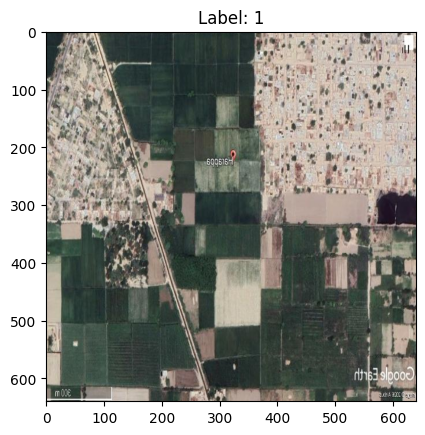

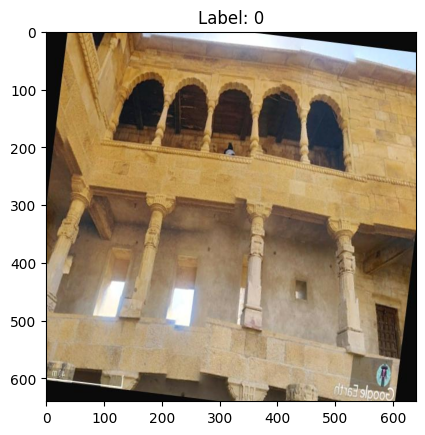

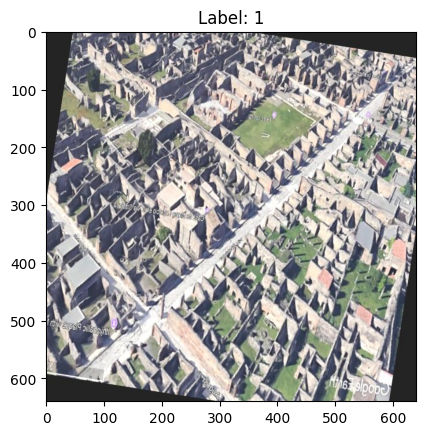

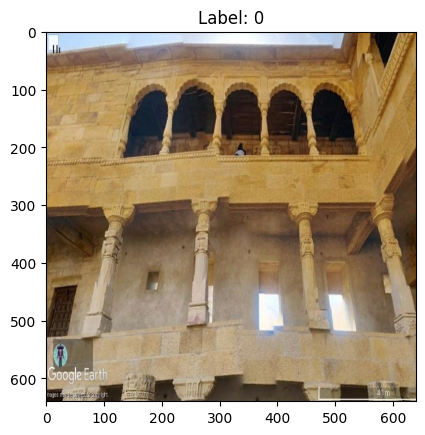

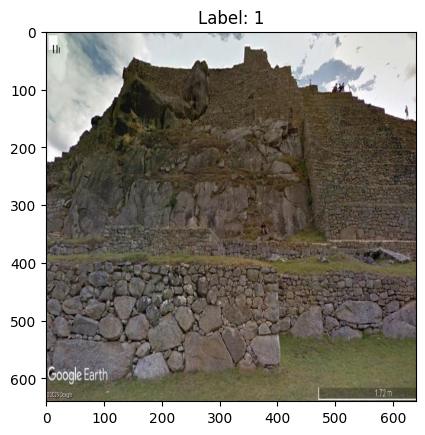

In [ ]:
# Verify the slope+vegetation index rule prediction
import matplotlib.pyplot as plt
import cv2

sample_idx = np.random.randint(0, len(images), 5)
for i in sample_idx:
    img_path = os.path.join(train_img_path, images[i])
    img = cv2.imread(img_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Label: {y[i]}")
    plt.show()

In [ ]:
# Convert to the numpy
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(116, 4) (116,)


In [ ]:
# Train-Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train the XGBoost
!pip install xgboost
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, max_depth=5)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# For save the erosion model
model.save_model("erosion_model.json")

In [ ]:
# Download the erosion model
from google.colab import files
files.download("erosion_model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Check the size of erosion model
import os

size = os.path.getsize("erosion_model.json") / (1024*1024)
print(f"Size: {size:.2f} MB")

Size: 0.05 MB


In [ ]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np

y_pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

RMSE: 0.0
R2 Score: 1.0
Accuracy: 1.0


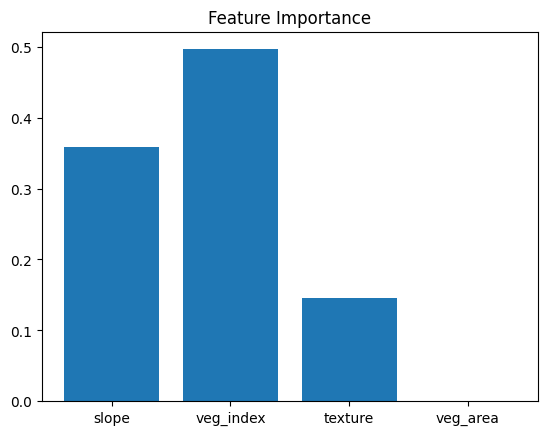

In [ ]:
# Feature Importance
import matplotlib.pyplot as plt

plt.bar(["slope","veg_index","texture","veg_area"], model.feature_importances_)
plt.title("Feature Importance")
plt.show()

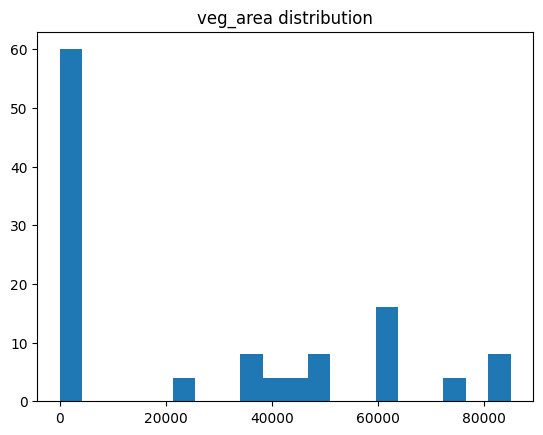

Min: 47.0 Max: 85024.0 Mean: 26321.931034482757


In [ ]:
# Check veg_area distribution
import matplotlib.pyplot as plt

veg_area = X[:,3]  # veg_area column
plt.hist(veg_area, bins=20)
plt.title("veg_area distribution")
plt.show()

print("Min:", veg_area.min(), "Max:", veg_area.max(), "Mean:", veg_area.mean())

In [ ]:
# Prepare the Image Coordinates
import pandas as pd
import numpy as np

# Number of images
n = len(images)  # images list from your dataset

# Create dummy coordinates (for visualization)
lats = np.linspace(28.7040, 28.7055, n)
lons = np.linspace(77.1010, 77.1035, n)

# Create dataframe
df = pd.DataFrame({
    "image_name": images,
    "lat": lats,
    "lon": lons,
    "label": y  # 0 = stable, 1 = erosion-prone
})

print("Sample dataframe:")
print(df.head())

Sample dataframe:
                                          image_name        lat        lon  \
0  Rakhigarhi_image_jpg.rf.428b3d5d1e2fe49a986fa4...  28.704000  77.101000   
1  Rameswaram_image_jpg.rf.d10b1dfbc5e70f253bb91b...  28.704013  77.101022   
2  Mathura_image_jpg.rf.64d77ffae390f8ae44a3cd7b8...  28.704026  77.101043   
3  MachuPicchu_image_jpg.rf.4a69c7b1b4c551ecc6ba7...  28.704039  77.101065   
4  Rakhigarhi_image_jpg.rf.138b874b06278c49b2c52f...  28.704052  77.101087   

   label  
0      1  
1      1  
2      1  
3      1  
4      1  


In [ ]:
# Install the folium for map plotting
!pip install folium

In [ ]:
# Create basic scatter map
import folium

# Center map on mean coordinates
map_center = [df["lat"].mean(), df["lon"].mean()]
m = folium.Map(location=map_center, zoom_start=16)

# Plot each image as a circle
for idx, row in df.iterrows():
    color = "red" if row["label"] == 1 else "green"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=row["image_name"]
    ).add_to(m)

# Display map
m
# Red dots- Erosion-prone, Green dots- Stable